# Boreal structure dynamics in polygons: 2020

09 January 2025  
Paul Montesano, PhD

Update to `build_stack.py` to change output from `mosaic_reader()` from `.as_masked()` to `.array` after `rio_tiler` updated `ImageData`   
-- Todo: commit

Built from `code/maap_tools/extent_report.ipynb`

In [1]:
import s3fs
s3 = s3fs.S3FileSystem(anon=True)

In [1]:
try:
    import contextily as ctx
except ModuleNotFoundError:
    print('Need to pip install packages...')
    !pip install contextily
    import contextily as ctx
    
import geopandas as gpd
import pandas as pd
import rasterio
import glob
import os
#import rioxarray
import fiona
from pyproj import CRS, Transformer

import sys
sys.path.append('/projects/code/icesat2_boreal/lib')
import ExtractUtils
import CovariateUtils

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import rasterio
from rasterio.plot import show_hist, show
import numpy.ma as ma
from build_stack import *

from plotnine import *
print("Importing packages complete.")
    
# font = {'family' : 'normal',
#         'weight' : 'bold',
#         'size'   : 12}

# plt.rc('font', **font)

NASA MAAP
Importing packages complete.


In [2]:
from folium import Map, TileLayer, GeoJson, LayerControl, Icon, Marker, features, Figure, CircleMarker
from folium import plugins

In [3]:
import maplib_folium
import tileslib

Registering the mosaic with Titiler...
{'id': '6d69551f-2c13-4af6-a9a3-1ee2078a1ea2', 'links': [{'href': 'https://titiler.maap-project.org/mosaics/6d69551f-2c13-4af6-a9a3-1ee2078a1ea2', 'rel': 'self', 'type': 'application/json', 'title': 'Self'}, {'href': 'https://titiler.maap-project.org/mosaics/6d69551f-2c13-4af6-a9a3-1ee2078a1ea2/mosaicjson', 'rel': 'mosaicjson', 'type': 'application/json', 'title': 'MosaicJSON'}, {'href': 'https://titiler.maap-project.org/mosaics/6d69551f-2c13-4af6-a9a3-1ee2078a1ea2/tilejson.json', 'rel': 'tilejson', 'type': 'application/json', 'title': 'TileJSON'}, {'href': 'https://titiler.maap-project.org/mosaics/6d69551f-2c13-4af6-a9a3-1ee2078a1ea2/tiles/{z}/{x}/{y}', 'rel': 'tiles', 'type': 'application/json', 'title': 'Tiles'}, {'href': 'https://titiler.maap-project.org/mosaics/6d69551f-2c13-4af6-a9a3-1ee2078a1ea2/WMTSCapabilities.xml', 'rel': 'wmts', 'type': 'application/json', 'title': 'WMTS'}]}
Registering the mosaic with Titiler...
{'id': 'e342c497-2ea4-4

# Get the dictionary created from the building of the extent-level stack
code/maap_tools/notebooks/extent_stack_boreal_fires.ipynb

In [328]:
DO_FIRE = False
if DO_FIRE:
    POLY_TYPE = 'firedpy'
    FIELDS_LIST = ['index','last_date']
    ALIAS_LIST = ['Fire idx:','Last fire:']
    fire_date = EXTENT_gdf.iloc[0].last_date
else:
    POLY_TYPE = 'HYBAS'
    FIELDS_LIST = ['HYBAS_ID']
    ALIAS_LIST = ['Hybas ID:']
    fire_date = None

In [317]:
ID = '150725'  # AK arctic circle #'7060157640'
ID = '1386576' # Siberian larch fire belt
ID = '103664'  # Northern Quebec
ID = 1103890 # fire
ID = 8060327990 # HYBAS
TILE_NUM = ID

In [318]:
MAINDIR = 's3://maap-ops-workspace/shared/nathanmthomas/analyze_agb'
STACKDIR = f'{MAINDIR}/output_mask_agb'

MAINDIR = 's3://maap-ops-workspace/shared/montesano/local_output/extent_stack_boreal_fire/output'.replace('s3://maap-ops-workspace/shared/montesano','/projects/my-public-bucket')
STACKDIR = f'{MAINDIR}/build_stack_clips'

BASIN_COG_DICT = {
    'landcover_cog_fn': f'{STACKDIR}/esa_worldcover_v100_2020_{ID}_cog.tif',
    'biomass_cog_fn':   f'{STACKDIR}/biomass_v2_1_{ID}_cog.tif',
    'height_cog_fn':    f'{STACKDIR}/height_v2_1_{ID}_cog.tif',
    'standage_cog_fn':  f'{STACKDIR}/standage_{ID}_cog.tif',
    'extent_gdf_fn':    f'{STACKDIR}/{POLY_TYPE}_boreal_reprj_clip_{ID}.gpkg',
    'tcc2020_cog_fn':   f'{STACKDIR}/tcc2020_{ID}_cog.tif',
    'tccslope_cog_fn':  f'{STACKDIR}/tccslope_{ID}_cog.tif',
    'tccpvalue_cog_fn': f'{STACKDIR}/tccpvalue_{ID}_cog.tif'
}

In [319]:
BASIN_COG_DICT['extent_gdf_fn']

'/projects/my-public-bucket/local_output/extent_stack_boreal_fire/output/build_stack_clips/HYBAS_boreal_reprj_clip_8060327990.gpkg'

In [320]:
# Calc extent area
extent_id = BASIN_COG_DICT['extent_gdf_fn'].split('_')[-2]

# Get extent gdf
EXTENT_gdf = gpd.read_file(BASIN_COG_DICT['extent_gdf_fn'])

basin_area_ha = EXTENT_gdf.area.to_list()[0] / 1e4
print(f'Area (ha.) of extent id {extent_id}:\t\t{round(basin_area_ha,2)}')

Area (ha.) of extent id clip:		2825568.62


## Map stand age & polygon

In [321]:
import importlib
importlib.reload(maplib_folium)

<module 'maplib_folium' from '/projects/code/icesat2_boreal/lib/maplib_folium.py'>

In [ ]:
maplib_folium.MAP_REGISTERED_DPS_RESULTS(
                                gpd.read_file(mosaiclib.boreal_tile_index_path),
                                None, 
                                CHECK_TILES_NAME=' ',
                                map_width=750, map_height=500, SHOW_WIDGETS=False,
                                ADD_TILELAYER = [  
                                                    tileslib.MISC_TILES_LAYER_DICT['AGE2020'],
                                                    tileslib.MISC_TILES_LAYER_DICT['TCCTREND2020'],
                                                    tileslib.MISC_TILES_LAYER_DICT['LC2020'],
                                                    tileslib.HT_TILE_LAYER_DICT['2020_v2.1'],
                                                    tileslib.AGB_TILE_LAYER_DICT['2020_v2.1'],
                                ],
                                ADD_GEOJSONLAYER = [GeoJson(
                                                        data=EXTENT_gdf.to_crs("EPSG:4326").to_json(),
                                                        name=POLY_TYPE,
                                                        style_function=lambda x: {'fillColor': '#orange', 'color': 'orange', 'weight' : 0.75, 'opacity': 1, 'fillOpacity': 0.0},
                                                        tooltip=features.GeoJsonTooltip(fields=FIELDS_LIST, aliases=ALIAS_LIST)
                                                        )
                                                    ]
)


#### Plot clip extent within boreal 
This will fail if the TILE_NUM specified is NOT in the data frame

In [327]:
xmin, xmax, ymin, ymax = [-170, -50, 40, 80] #[-180, 180, 40, 80]
if EXTENT_gdf.to_crs("EPSG:4326").centroid.x[0] > 0:
    print('Eurasia')
    xmin, xmax, ymin, ymax = [0, 180, 40, 80]

/tmp/ipykernel_16147/2548120936.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [330]:
boreal_gdf = gpd.read_file('s3://maap-ops-workspace/shared/montesano/databank/arc/wwf_circumboreal_Dissolve.geojson', bbox=(xmin, ymin, xmax, ymax))
hybas_border = gpd.read_file('s3://maap-ops-workspace/shared/nathanmthomas/analyze_agb/input_zones/hybas_lake_NORTHERN_lev03_vc1.gpkg', bbox=(xmin, ymin, xmax, ymax))

Extent ID: clip
Plot...
Plot...


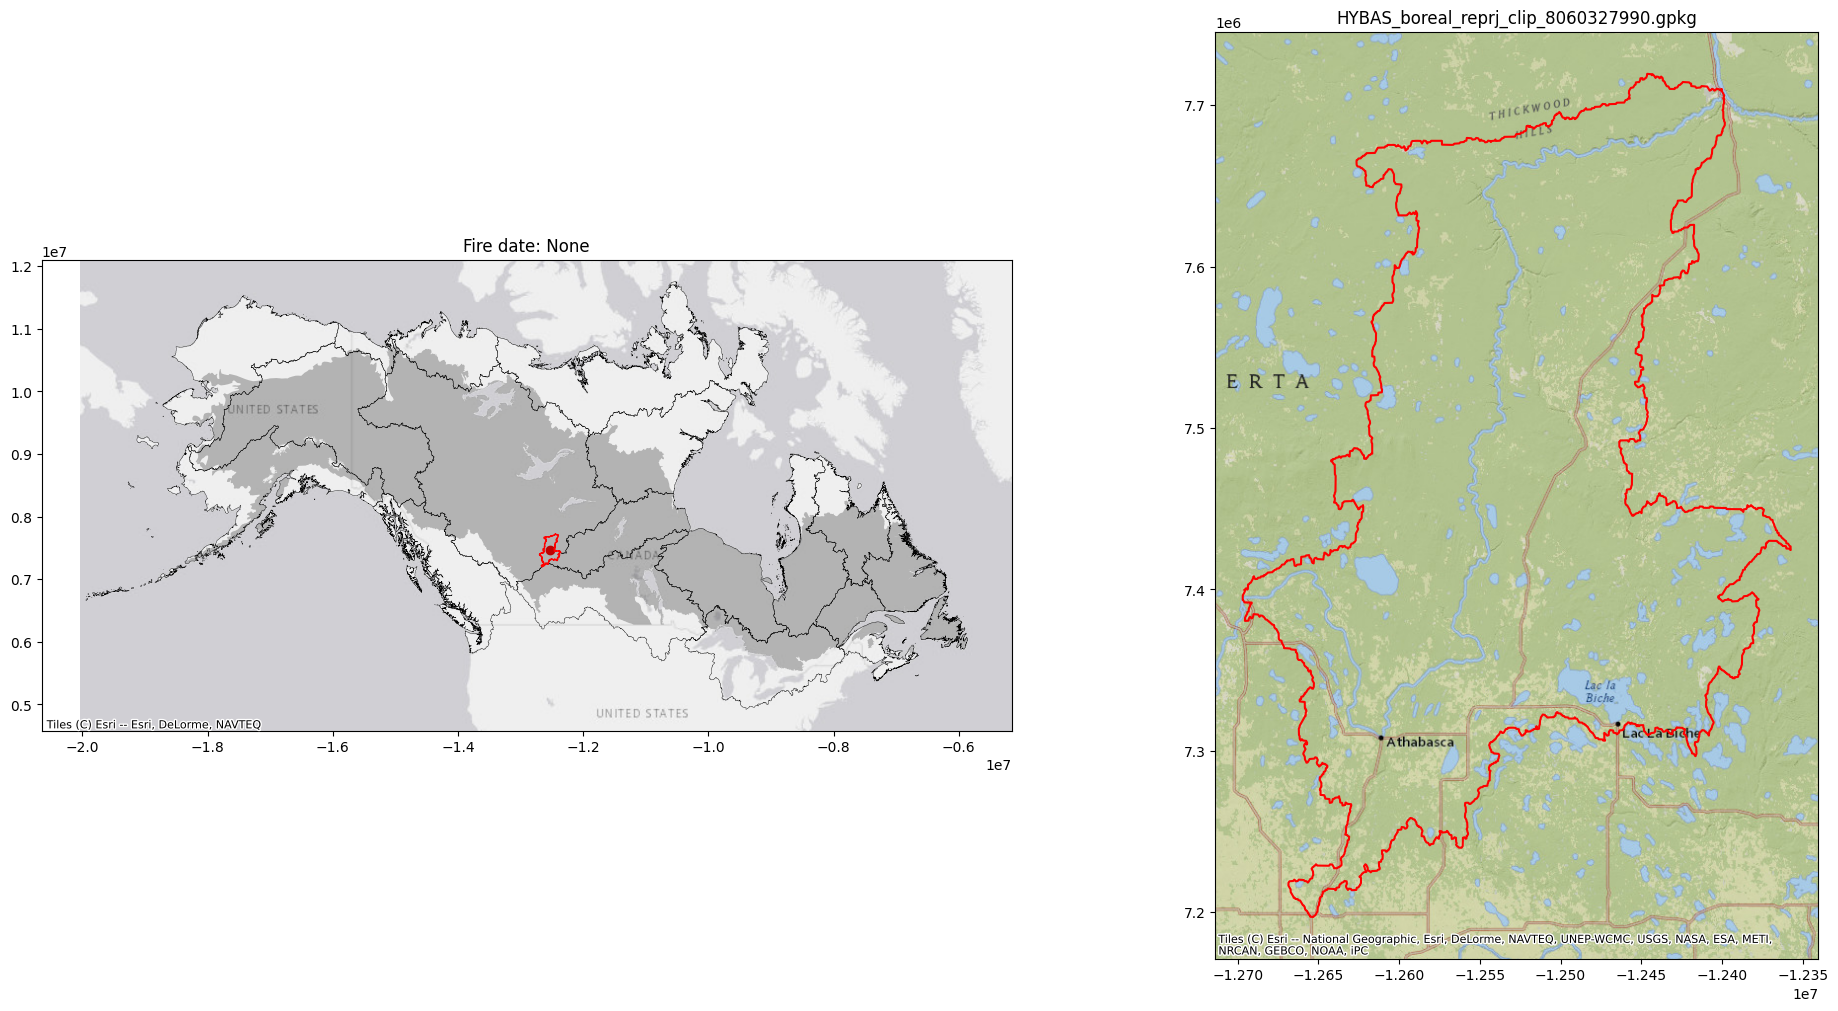

In [331]:
SHOW_FULL_EXTENT = False

print(f'Extent ID: {extent_id}')

print('Plot...')
f, (ax1, ax2) = plt.subplots(figsize=(20, 10), ncols=2, nrows=1, constrained_layout=True)
ax1.set_title(f"Fire date: {fire_date}")
ax2.set_title(os.path.basename(BASIN_COG_DICT['extent_gdf_fn']))

# Get boreal domain from wwf 
SUB_DOMAIN_selection_geometry = boreal_gdf.cx[xmin:xmax, ymin:ymax].iloc[0].geometry

# Get the basins
hybas_border[hybas_border.intersects(SUB_DOMAIN_selection_geometry)].to_crs(3857).boundary.plot(linewidth=0.25, color='black', ax=ax1)

EXTENT_gdf.to_crs(3857).boundary.plot(color='red', linewidth=1, ax=ax1)
    
print('Plot...')
EXTENT_gdf.centroid.to_crs(3857).plot(color='red', ax=ax1)
EXTENT_gdf.to_crs(3857).boundary.plot(color='red', ax=ax2)
boreal_gdf.cx[xmin:xmax, ymin:ymax].to_crs(3857).plot(alpha=0.25, color='black', marker = '---', ax=ax1)
ctx.add_basemap(ax1,  source=ctx.providers.Esri.WorldGrayCanvas)
ctx.add_basemap(ax2,  source=ctx.providers.Esri.NatGeoWorldMap)

# Create fire poly report of AGB for each LC class

In [332]:
BASIN_COG_DICT

{'landcover_cog_fn': '/projects/my-public-bucket/local_output/extent_stack_boreal_fire/output/build_stack_clips/esa_worldcover_v100_2020_8060327990_cog.tif',
 'biomass_cog_fn': '/projects/my-public-bucket/local_output/extent_stack_boreal_fire/output/build_stack_clips/biomass_v2_1_8060327990_cog.tif',
 'height_cog_fn': '/projects/my-public-bucket/local_output/extent_stack_boreal_fire/output/build_stack_clips/height_v2_1_8060327990_cog.tif',
 'standage_cog_fn': '/projects/my-public-bucket/local_output/extent_stack_boreal_fire/output/build_stack_clips/standage_8060327990_cog.tif',
 'extent_gdf_fn': '/projects/my-public-bucket/local_output/extent_stack_boreal_fire/output/build_stack_clips/HYBAS_boreal_reprj_clip_8060327990.gpkg',
 'tcc2020_cog_fn': '/projects/my-public-bucket/local_output/extent_stack_boreal_fire/output/build_stack_clips/tcc2020_8060327990_cog.tif',
 'tccslope_cog_fn': '/projects/my-public-bucket/local_output/extent_stack_boreal_fire/output/build_stack_clips/tccslope_80603

In [333]:
import fiona
import rasterio.mask

In [334]:
with fiona.open(BASIN_COG_DICT['extent_gdf_fn'], "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]

In [335]:
# ESA Worldcover
names_worldcover = [ 'Trees', 'Shrubland', 'Grassland','Cropland',\
                    'Built-up',
                    'Barren/sparse','Snow and ice','Open water','Herbaceous wetland','Mangroves','Moss and lichen']
cols_worldcover = [ "#006400","#ffbb22","#ffff4c","#f096ff",\
                   "#fa0000",\
                   "#b4b4b4","#f0f0f0","#0064c8","#0096a0","#00cf75","#fae6a0"]

# The land cover values in which you want to summarize AGB
values_worldcover = [10,20,30,40,\
                     50,\
                     60,70,80,90,95,100] 

cmap_worldcover = ListedColormap(cols_worldcover)
norm_worldcover = BoundaryNorm(values_worldcover, len(cols_worldcover))

dict_worldcover_colors = dict(zip(names_worldcover, cols_worldcover))
dict_worldcover_colors

dict_worldcover_values = dict(zip(names_worldcover, values_worldcover))
dict_worldcover_values

{'Trees': 10,
 'Shrubland': 20,
 'Grassland': 30,
 'Cropland': 40,
 'Built-up': 50,
 'Barren/sparse': 60,
 'Snow and ice': 70,
 'Open water': 80,
 'Herbaceous wetland': 90,
 'Mangroves': 95,
 'Moss and lichen': 100}

In [336]:
# TP Stand Age
names_standage = ['non-forest', 'young forest', 'mature forest']
colors_standage = ['gray','#e41a1c','#4daf4a']
values_standage = [0,1,2]

cmap_standage = ListedColormap(colors_standage)
norm_standage = BoundaryNorm(values_standage, len(colors_standage))

dict_standage_colors = dict(zip(names_standage, colors_standage))
dict_standage_colors

dict_standage_values = dict(zip(names_standage, values_standage))
dict_standage_values

{'non-forest': 0, 'young forest': 1, 'mature forest': 2}

In [337]:
# TP TCC change rate
names_tcctrend = ['decrease', 'stable', 'increase']
colors_tcctrend = ['#a6611a','#f5f5f5','#018571']
values_tcctrend = [-0.5,0,0.5]

cmap_tcctrend = ListedColormap(colors_tcctrend)
norm_tcctrend = BoundaryNorm(values_tcctrend, len(colors_tcctrend))

dict_tcctrend_colors = dict(zip(names_tcctrend, colors_tcctrend))
dict_tcctrend_colors

dict_tcctrend_values = dict(zip(names_tcctrend, values_tcctrend))
dict_tcctrend_values

{'decrease': -0.5, 'stable': 0, 'increase': 0.5}

### Clips and LC tallies

LC nodata value: 0.0
Area (ha.) of extent 8060327990:		2825568.621586427
lc_arr shape: (9329, 8043)
Biomass nodata value: -9999.0
agb_arr shape: (9329, 8043)

0 Trees 10
	# land cov pixels in class:			21868018
	# Total area (ha.) in class:			1968121.6199999999 (69.65% of extent)
	Mg/ha (min,mean,med,max):				0.56, 53.98, 45.05 , 320.94
	Total AGB (Mg) in class:			106235256.0 (8.32% of extent biomass)
1 Shrubland 20
	# land cov pixels in class:			2183391
	# Total area (ha.) in class:			196505.19 (6.95% of extent)
	Mg/ha (min,mean,med,max):				0.81, 11.51, 9.49 , 166.82
	Total AGB (Mg) in class:			2262666.5 (0.18% of extent biomass)
2 Grassland 30
	# land cov pixels in class:			4325141
	# Total area (ha.) in class:			389262.69 (13.78% of extent)
	Mg/ha (min,mean,med,max):				0.24, 13.05, 8.33 , 251.74
	Total AGB (Mg) in class:			5081094.5 (0.4% of extent biomass)
3 Cropland 40
	# land cov pixels in class:			1374121
	# Total area (ha.) in class:			123670.89 (4.38% of extent)
	Mg/ha (min,m

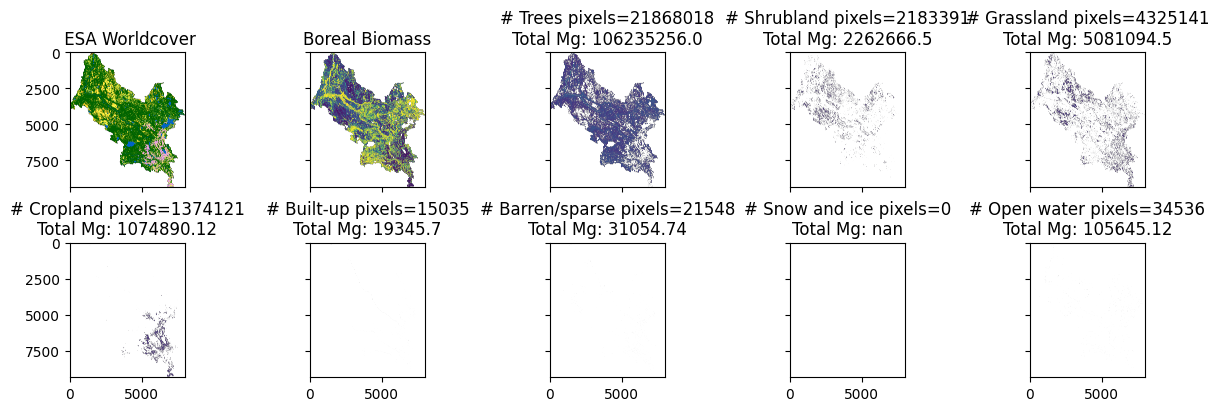

In [338]:
# Subplots
# LC map + AGB + AGB for each LC value in names_worldcover
num_groups = 2 + len(values_worldcover)
ncols = 5
nrows = (num_groups + 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 2 * nrows), 
                         constrained_layout=True, sharex=True, sharey=True)
axes = axes.ravel()

with rasterio.open(BASIN_COG_DICT['landcover_cog_fn']) as dataset:
    
    lc_arr, out_transform = rasterio.mask.mask(dataset, shapes, crop=True)
    lc_arr = lc_arr[0,:,:]
    lc_meta = dataset.profile
    print(f"LC nodata value: {dataset.nodata}")
    print(f"Area (ha.) of extent {ID}:\t\t{basin_area_ha}")
    print(f"lc_arr shape: {lc_arr.shape}")
    
    # NoData value is 0; mask this
    lc_arr = np.ma.masked_where( lc_arr == 0, lc_arr)
    
    #cols_worldcover = ["white","green","orange","yellow","purple","red","brown","gray","blue","pink","cyan","black"]
    #cols_mask = ["white", "red"]
    #values_mask = [0,1]

    #cmap_masked = ListedColormap(cols_mask)
    #norm_masked= BoundaryNorm(values_mask, len(cols_mask))
    
    axes[0].imshow(lc_arr, cmap=cmap_worldcover, norm=norm_worldcover)
    axes[0].set_title(f" ESA Worldcover")
    
    # Find sum of AGB per LC class
    # multiply by AGB values and sum
    with rasterio.open(BASIN_COG_DICT['biomass_cog_fn']) as dataset_agb:
        
        agb_arr, out_transform = rasterio.mask.mask(dataset_agb, shapes, crop=True)
        agb_arr = agb_arr[0,:,:]
        #print('\n', dataset_agb.profile,'\n')
        print(f"Biomass nodata value: {dataset_agb.nodata}")
        
        #agb_arr = np.ma.masked_where( (lc_arr==0) | (agb_arr<0), agb_arr)
        agb_arr = np.ma.masked_where(  (agb_arr<0), agb_arr)
        total_mg_all = np.nansum(agb_arr)
        
        print(f"agb_arr shape: {agb_arr.shape}\n")
        axes[1].imshow(agb_arr, clim=(0,75))
        axes[1].set_title(f"Boreal Biomass")
    
        for i, (ax, LC_VALUE) in enumerate(zip(axes[2:], values_worldcover)):

            LC_NAME = names_worldcover[i]
            print(i, LC_NAME, LC_VALUE)

            # For LC value of interest
            #lc_agb_arr = np.ma.masked_where( (lc_arr == 0) | (agb_arr < 0) | (lc_arr != LC_VALUE) , agb_arr)
            lc_agb_arr = np.ma.masked_where( (lc_arr != LC_VALUE) , agb_arr)
            
            num_lc_pixels_in_mask = lc_agb_arr[~np.isnan(lc_agb_arr)].count() 
            num_lc_pixels_in_mask = lc_agb_arr.count()
            total_lc_area_ha = num_lc_pixels_in_mask * area_pix_ha
            
            print(f"\t# land cov pixels in class:\t\t\t{num_lc_pixels_in_mask}")
            print(f"\t# Total area (ha.) in class:\t\t\t{total_lc_area_ha} ({round(100 * total_lc_area_ha / basin_area_ha,2)}% of extent)")
            
            total_mg_lc = np.nan
            
            if False and LC_VALUE == 40:
                list_of_vals = lc_agb_arr[lc_agb_arr.mask == False].tolist()
                print(list_of_vals)
                #print(f"\t\t{(sum(list_of_vals) / num_lc_pixels_in_mask) * area_pix_ha}")
                
            if LC_VALUE == 10:
                trees_lc_agb_arr = lc_agb_arr
            
            if num_lc_pixels_in_mask > 0:

                #### --- ValueError: assignment destination is read-only 
                try:
                    print(f"\tMg/ha (min,mean,med,max):\t\t\t\t{round(np.nanmin(lc_agb_arr)/1,2)}, {round(np.nanmean(lc_agb_arr)/1,2)}, {round(np.ma.median(lc_agb_arr)/1,2)} , {round(np.nanmax(lc_agb_arr)/1,2)}")
                except:
                    print(f"\tMg/ha (min,mean,med,max):\t\t\t\tERROR")

                # ***To get error bars on total (Mg), need to have mean AGB raster and sd AGB raster, and use them to sample a normal distribution of AGB values per pixel, n=100 times per pixel?
                # Then get all the totals from the n layers, and get the mean total and the sd of the total
                #total_mg_lc = (lc_agb_arr.sum() / num_lc_pixels_in_mask) * area_pix_ha
                total_mg_lc = round(np.nansum(lc_agb_arr * area_pix_ha), 2)/1
                print(f"\tTotal AGB (Mg) in class:\t\t\t{round( total_mg_lc, 2)} ({round(100 * total_mg_lc / total_mg_all,2)}% of extent biomass)")
            
            # To plot with a legend: https://www.earthdatascience.org/courses/use-data-open-source-python/intro-raster-data-python/raster-data-processing/classify-plot-raster-data-in-python/
            ax.imshow(lc_agb_arr, clim=(-100,700))
            ax.set_title(f"# {LC_NAME} pixels={num_lc_pixels_in_mask}\nTotal Mg: {round(total_mg_lc,2)}")
            
            #show(lc_mask, cmap=cmap_masked, norm=norm_masked)
            #show_hist(lc_mask, bins=len(values_masked)+1, lw=0.0, stacked=False, alpha=0.3, histtype='stepfilled', title="Histogram of ESA Worldcover Class Values")

In [339]:
try:
    from matplotlib_scalebar.scalebar import ScaleBar
except:
    !pip install -U matplotlib-scalebar
    from matplotlib_scalebar.scalebar import ScaleBar
    
def add_colorbar(mappable, label):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.pyplot as plt
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label(label)
    plt.sca(last_axes)
    return cbar

In [340]:
dict_worldcover_colors.get('Trees')

'#006400'

Extent:		8060327990
Total ha.:		2690823.87
Mean Mg/ha:		42.67
Total Pg.:		0.1148
Mean Mg/ha in trees:	53.98
Total Pg. in trees:	0.1062


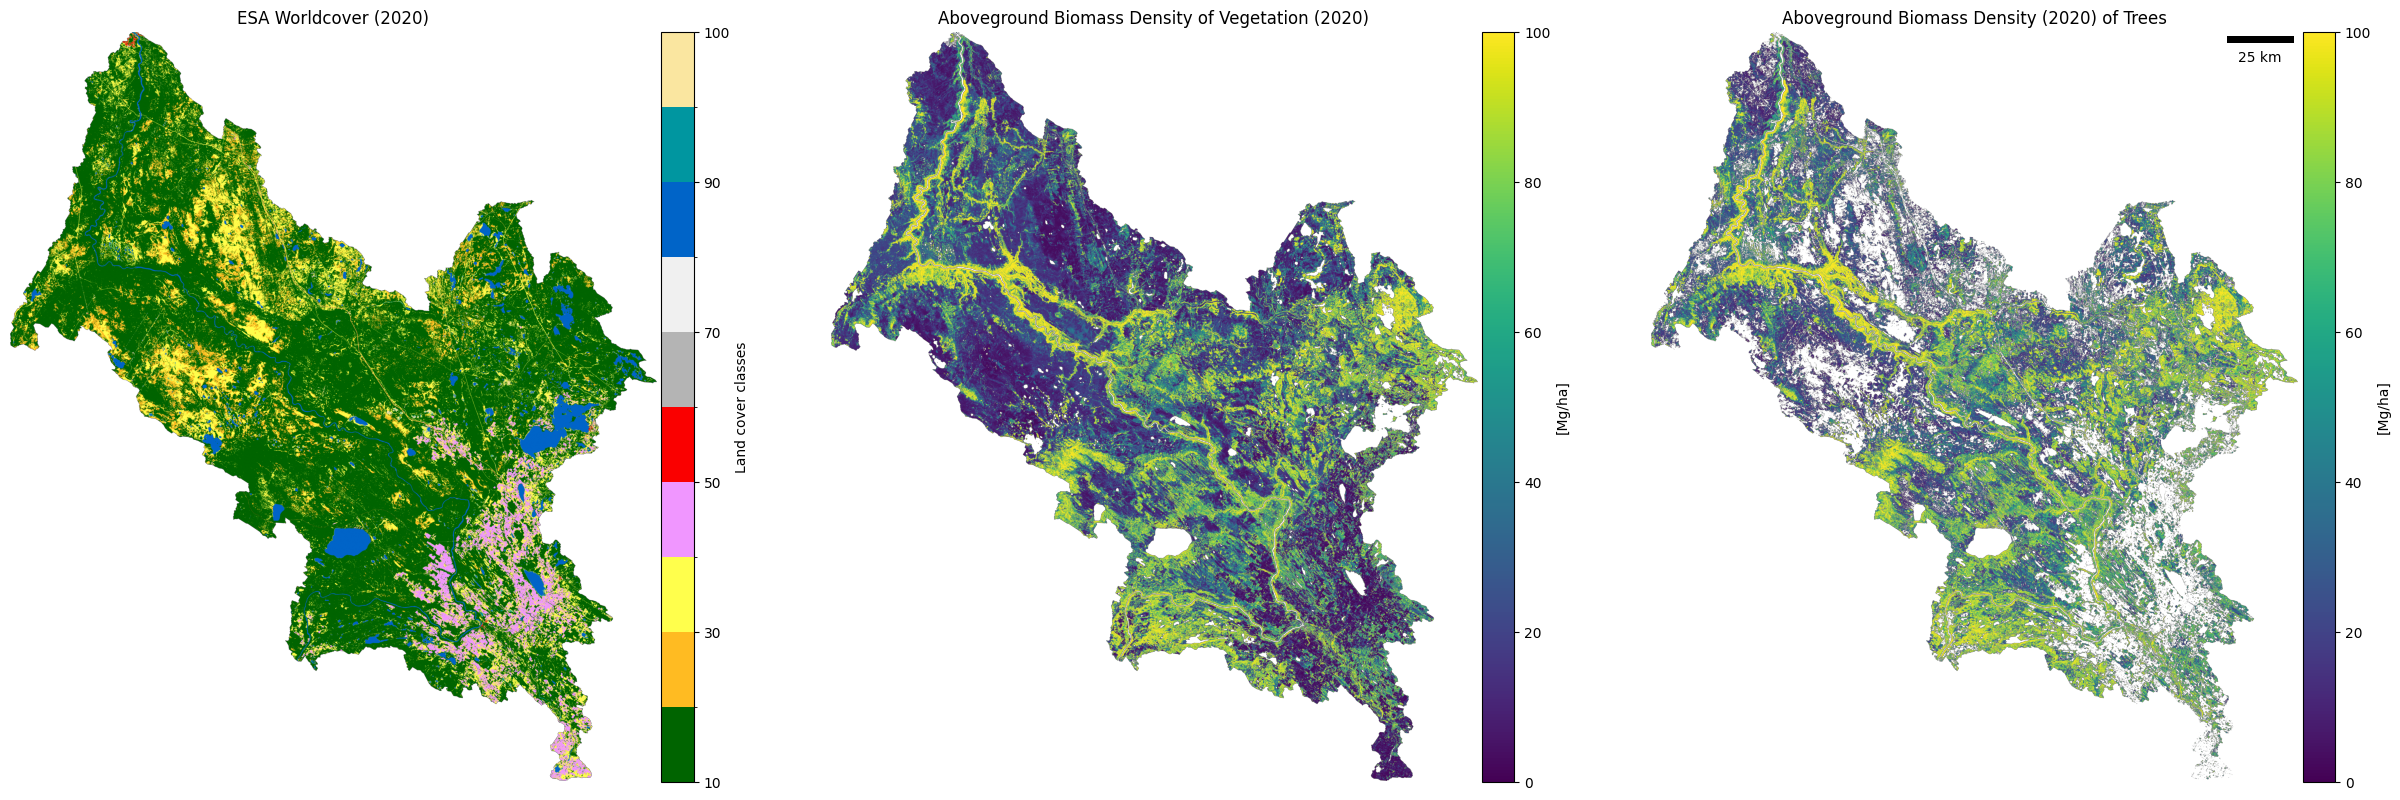

In [341]:
LC_VAL = dict_worldcover_values.get('Trees') #10

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(30,30), sharex=True, sharey=True)

# Scalebar doesnt seem correct
scalebar = ScaleBar(30) # <-- each pixel (unit) is 30m
plt.gca().add_artist(scalebar)

##########
# AGB arrays
# With a water mask
agb_arr_masked = np.ma.masked_where( (lc_arr == 0  ) | (lc_arr == 80) , agb_arr)

##########
# Without a water mask
#agb_arr_masked = np.ma.masked_where( (lc_arr == 0  )  ,agb_arr)

##########
# AGB density of ESA Worldcover v1 2020 trees 
agb_arr_masked_trees = np.ma.masked_where( (lc_arr != LC_VAL  ), agb_arr_masked)

print(f"Extent:\t\t{ID}")
print(f"Total ha.:\t\t{(agb_arr_masked[~np.isnan(agb_arr_masked)].count() * area_pix_ha ) }")
print(f"Mean Mg/ha:\t\t{ round(np.nanmean(agb_arr_masked)/1,2) }")
print(f"Total Pg.:\t\t{round(np.nansum(agb_arr_masked)/1e9 * area_pix_ha,4) }")
print(f"Mean Mg/ha in trees:\t{ round(np.nanmean(agb_arr_masked_trees)/1,2) }")
print(f"Total Pg. in trees:\t{round(np.nansum(agb_arr_masked_trees)/1e9 * area_pix_ha, 4) }")

# Plots

# Showing only trees LC
#m2 = axes[1].imshow(lc_arr_trees, cmap=cmap_worldcover, norm=norm_worldcover)
# Showing all LC classes
m1 = axes[0].imshow(lc_arr, cmap=cmap_worldcover, norm=norm_worldcover)
add_colorbar(m1, 'Land cover classes')
axes[0].set_title('ESA Worldcover (2020)')
axes[0].axis('off')

m2 = axes[1].imshow(agb_arr_masked, clim=(0,100) )
add_colorbar(m2, '[Mg/ha]')
m2 = axes[1].set_title('Aboveground Biomass Density of Vegetation (2020)')
axes[1].axis('off')

# Show AGB for tree
m3 = axes[2].imshow(agb_arr_masked_trees, clim=(0,100), cmap='viridis')
add_colorbar(m3, '[Mg/ha]')
m3 = axes[2].set_title('Aboveground Biomass Density (2020) of Trees')
axes[2].axis('off')

if False:
    # Convert AGB density to total
    m4 = axes[3].imshow(agb_arr_masked_trees* area_pix_ha, clim=(0,10), cmap='plasma')
    add_colorbar(m3, '[Mg]')
    m4 = axes[3].set_title('Aboveground Biomass (2020) of Trees')
    axes[3].axis('off')

# Carbon accumulation in forests  

C accumulation depends on current AGB and stand age  
ABoVE ICESat-2 Boreal maps give us AGB  
TerraPulse maps give us stand age, computed for 'Forest' pixels using the Landsat record (1984-2020)  
+ 0 values indicate no 'Forest'
+ 50 values indicate age older than Landsat record

### Clip to poly here

In [342]:
def read_clip_raster(r_fn, bandnum):
    with rasterio.open(r_fn) as dataset:
        arr3d, out_transform = rasterio.mask.mask(dataset, shapes, crop=True)
        arr = arr3d[bandnum-1,:,:]
    return arr

In [343]:
ndv_standage = 255
max_standage = 36
ndv_tccslope = 255
ndv_tcc = 255

# TerraPulse data
standage_arr = read_clip_raster(BASIN_COG_DICT['standage_cog_fn'], 1)
tccslope_arr = read_clip_raster(BASIN_COG_DICT['tccslope_cog_fn'], 1)
tcc2020_arr =  read_clip_raster(BASIN_COG_DICT['tcc2020_cog_fn'], 1)
tccpvalue_arr =  read_clip_raster(BASIN_COG_DICT['tccpvalue_cog_fn'], 1)

height_arr = read_clip_raster(BASIN_COG_DICT['height_cog_fn'], 1)

Extent:		8060327990

Total ha.:		1968121.6199999999

Mean AGB Mg/ha in all classes (even water):		42.65999984741211
Total AGB Pg. in all classes (even water):	0.1149
Water AGB adds additional 0.000106 Pg. to the Total land AGB, an increase of 0.092 %

Mean AGB Mg/ha:		42.66999816894531
Total AGB Pg.:		0.1148

Mean AGB Mg/ha in trees:	53.97999954223633
Total AGB Pg. in trees:	0.1062
Tree AGB is 0.9252 of Total land AGB

Mean Net C accumulation in trees:	0.6499999761581421 MgC/ha/yr
Total Pg. C in trees:	0.0012 Pg
Mean Net C accumulation in all classes:	0.5699999928474426 MgC/ha/yr
Total Pg. C in all classes:	0.0013 Pg
Tree C is 0.9364 of Total land aboveground C

This C proportion doesnt match the AGB proportion due to pixel with stand age = 0
---This doesnt make sense yet --> Adjusted Tree C is 0.6001 of Total land aboveground C



(-0.5, 8042.5, 9328.5, -0.5)

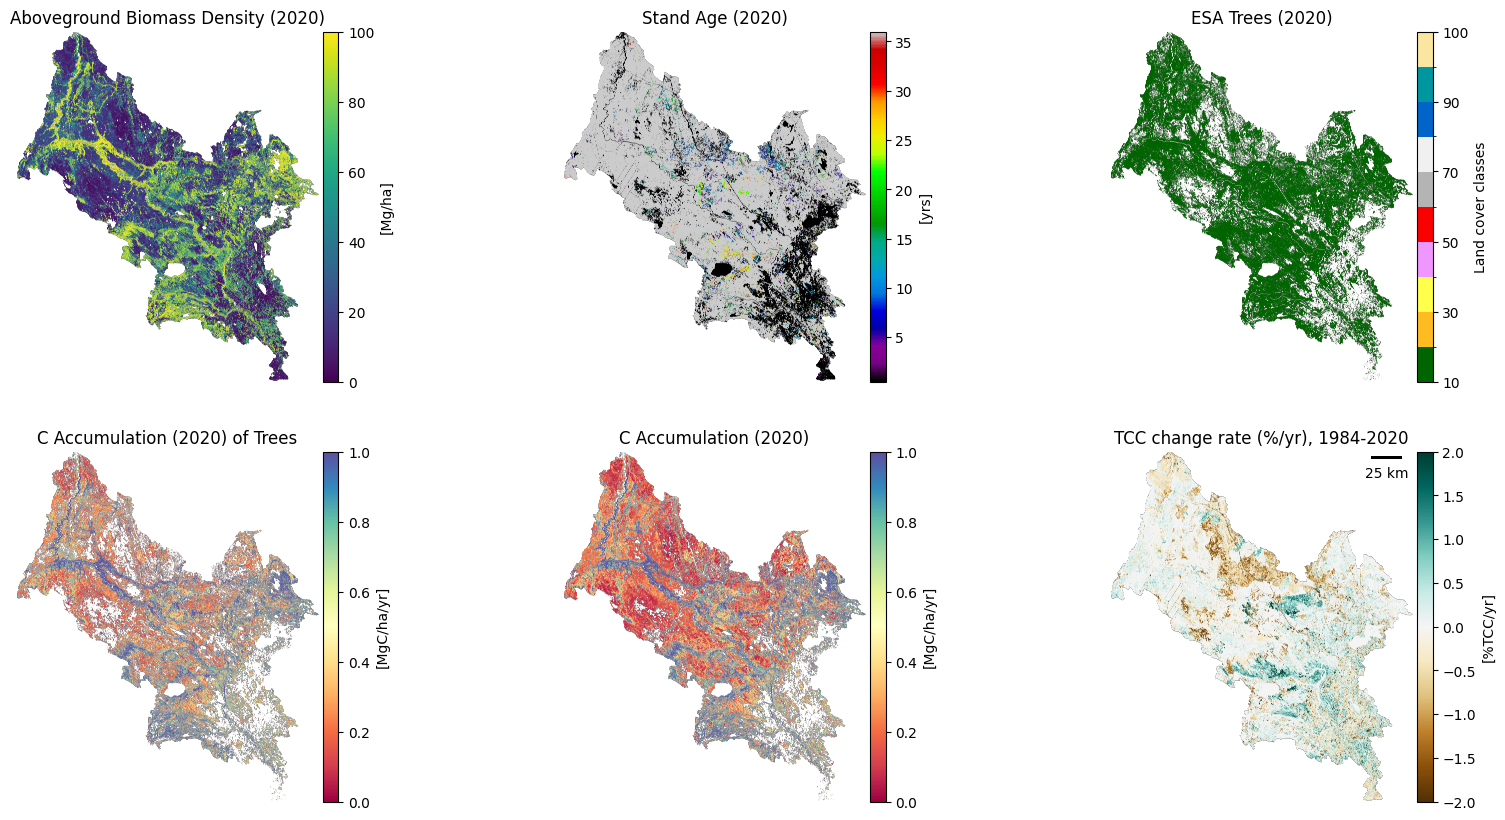

In [344]:
val_lc_nodata, val_lc_trees, val_lc_water = [0, 10, 80]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20,10), sharex=True, sharey=True)
axes = axes.ravel()
# Scalebar doesnt seem correct
scalebar = ScaleBar(30) # <-- each pixel (unit) is 30m
plt.gca().add_artist(scalebar)

#
# Stand age masked with its nodata
#
standage_arr_masked = np.ma.masked_where( (standage_arr == ndv_standage ), standage_arr) # <-- note, leaving in age = 0 here, technically not 'stands'? or just 'recently disturbed stands' - how to get C accumulation when denom is 0?
standage_arr_masked_adj = np.ma.where(standage_arr_masked == 0, 0.5, np.ma.where(standage_arr_masked == 50, 36, standage_arr_masked)) # <-- instead of age = 0, age = 0.5
standage_arr_masked_trees = np.ma.masked_where( (lc_arr != val_lc_trees  ), standage_arr_masked)
standage_arr_masked_adj_trees = np.ma.masked_where( (lc_arr != val_lc_trees  ), standage_arr_masked_adj)

#
# LC masked with its nodata and water
#
lc_arr_masked = np.ma.masked_where( (lc_arr == val_lc_nodata  ) | (lc_arr == val_lc_water) , lc_arr)
lc_arr_trees = np.ma.masked_where( (lc_arr != val_lc_trees  )  , lc_arr_masked)

# TCC variables masked with its nodata
tccslope_arr = np.ma.masked_where( (tccslope_arr == ndv_tccslope ) , tccslope_arr)
tcc2020_arr = np.ma.masked_where( (tcc2020_arr == ndv_tcc ) , tcc2020_arr)

# AGB masked with lc nodata
agb_water_arr_masked = np.ma.masked_where( (lc_arr == val_lc_nodata  )  , agb_arr)
# ..and additionally with water
agb_arr_masked = np.ma.masked_where(  (lc_arr == val_lc_water) , agb_water_arr_masked)
# ..and additionally with ESA Worldover trees
agb_arr_masked_trees = np.ma.masked_where( (lc_arr != val_lc_trees  ), agb_arr_masked)

# Carbon accumulation per year (Annual net C accumulation rate)
ratio_c_agb = 0.5
netc_accum_arr = (agb_arr_masked * ratio_c_agb) / standage_arr_masked
netc_accum_arr_adj= (agb_arr_masked * ratio_c_agb) / standage_arr_masked_adj
netc_accum_arr_trees = (agb_arr_masked_trees * ratio_c_agb) / standage_arr_masked
netc_accum_arr_trees_adj = (agb_arr_masked_trees * ratio_c_agb) / standage_arr_masked_adj

# Get the total water AGB
land_water_agb_total = (np.nansum(agb_water_arr_masked)/1e9 * area_pix_ha)
land_agb_total = (np.nansum(agb_arr_masked)/1e9 * area_pix_ha)
water_agb_total = land_water_agb_total - land_agb_total

print(f"Extent:\t\t{TILE_NUM}\n")
print(f"Total ha.:\t\t{(agb_arr_masked_trees[~np.isnan(agb_arr_masked)].count() * area_pix_ha ) }\n")

print(f"Mean AGB Mg/ha in all classes (even water):\t\t{ round(np.nanmean(agb_arr),2) }")
print(f"Total AGB Pg. in all classes (even water):\t{round(np.nansum(agb_arr)/1e9 * area_pix_ha, 4) }")
print(f"Water AGB adds additional { round(water_agb_total, 6)} Pg. to the Total land AGB, an increase of { round(water_agb_total / land_agb_total * 100 , 3) } %\n")

# Land AGB
print(f"Mean AGB Mg/ha:\t\t{ round(np.nanmean(agb_arr_masked),2) }")
print(f"Total AGB Pg.:\t\t{round(np.nansum(agb_arr_masked)/1e9 * area_pix_ha,4) }\n")

# Tree AGB
print(f"Mean AGB Mg/ha in trees:\t{ round(np.nanmean(agb_arr_masked_trees),2) }")
print(f"Total AGB Pg. in trees:\t{round(np.nansum(agb_arr_masked_trees)/1e9 * area_pix_ha, 4) }")
print(f"Tree AGB is {round(  (np.nansum(agb_arr_masked_trees)/1e9 * area_pix_ha) / (np.nansum(agb_arr_masked)/1e9 * area_pix_ha)  , 4) } of Total land AGB\n")

# Carbon accumulation
print(f"Mean Net C accumulation in trees:\t{ round(np.nanmean( netc_accum_arr_trees),2) } MgC/ha/yr")
print(f"Total Pg. C in trees:\t{round(np.nansum(netc_accum_arr_trees)/1e9 * area_pix_ha, 4) } Pg")
print(f"Mean Net C accumulation in all classes:\t{ round(np.nanmean( netc_accum_arr),2) } MgC/ha/yr")
print(f"Total Pg. C in all classes:\t{round(np.nansum(netc_accum_arr)/1e9 * area_pix_ha, 4) } Pg")
print(f"Tree C is {round(  (np.nansum(netc_accum_arr_trees)/1e9 * area_pix_ha) / (np.nansum(netc_accum_arr)/1e9 * area_pix_ha)  , 4) } of Total land aboveground C\n")
print("This C proportion doesnt match the AGB proportion due to pixel with stand age = 0")
print(f"---This doesnt make sense yet --> Adjusted Tree C is {round(  (np.nansum(netc_accum_arr_trees_adj)/1e9 * area_pix_ha) / (np.nansum(netc_accum_arr_adj)/1e9 * area_pix_ha)  , 4) } of Total land aboveground C\n")

# Plots
# Biomass
m1 = axes[0].imshow(agb_arr_masked, clim=(0,100) )
add_colorbar(m1, '[Mg/ha]')
m1 = axes[0].set_title('Aboveground Biomass Density (2020)')
axes[0].axis('off')

# Age
m2 = axes[1].imshow(standage_arr_masked_adj, cmap='nipy_spectral')
add_colorbar(m2, '[yrs]')
axes[1].set_title('Stand Age (2020)')
axes[1].axis('off')
EXTENT_gdf.plot(ax=axes[1], facecolor='none', edgecolor='red')

# Showing trees instead of all LC classes
m3 = axes[2].imshow(lc_arr_trees, cmap=cmap_worldcover, norm=norm_worldcover)
add_colorbar(m3, 'Land cover classes')
axes[2].set_title('ESA Trees (2020)')
axes[2].axis('off')

# Carbon accumulation in trees
m4 = axes[3].imshow(netc_accum_arr_trees, clim=(0,1), cmap='Spectral')
add_colorbar(m4, '[MgC/ha/yr]')
m4 = axes[3].set_title('C Accumulation (2020) of Trees')
axes[3].axis('off')

# Carbon accumulation in all classes
m5 = axes[4].imshow(netc_accum_arr, clim=(0,1), cmap='Spectral')
add_colorbar(m5, '[MgC/ha/yr]')
m5 = axes[4].set_title('C Accumulation (2020)')
axes[4].axis('off')

# TCC trend 1984-2020
m6 = axes[5].imshow(tccslope_arr, clim=(-2,2), cmap='BrBG')
add_colorbar(m6, '[%TCC/yr]')
m6 = axes[5].set_title('TCC change rate (%/yr), 1984-2020')
axes[5].axis('off')

#### Check trees and C accum with larger maps

(-0.5, 8042.5, 9328.5, -0.5)

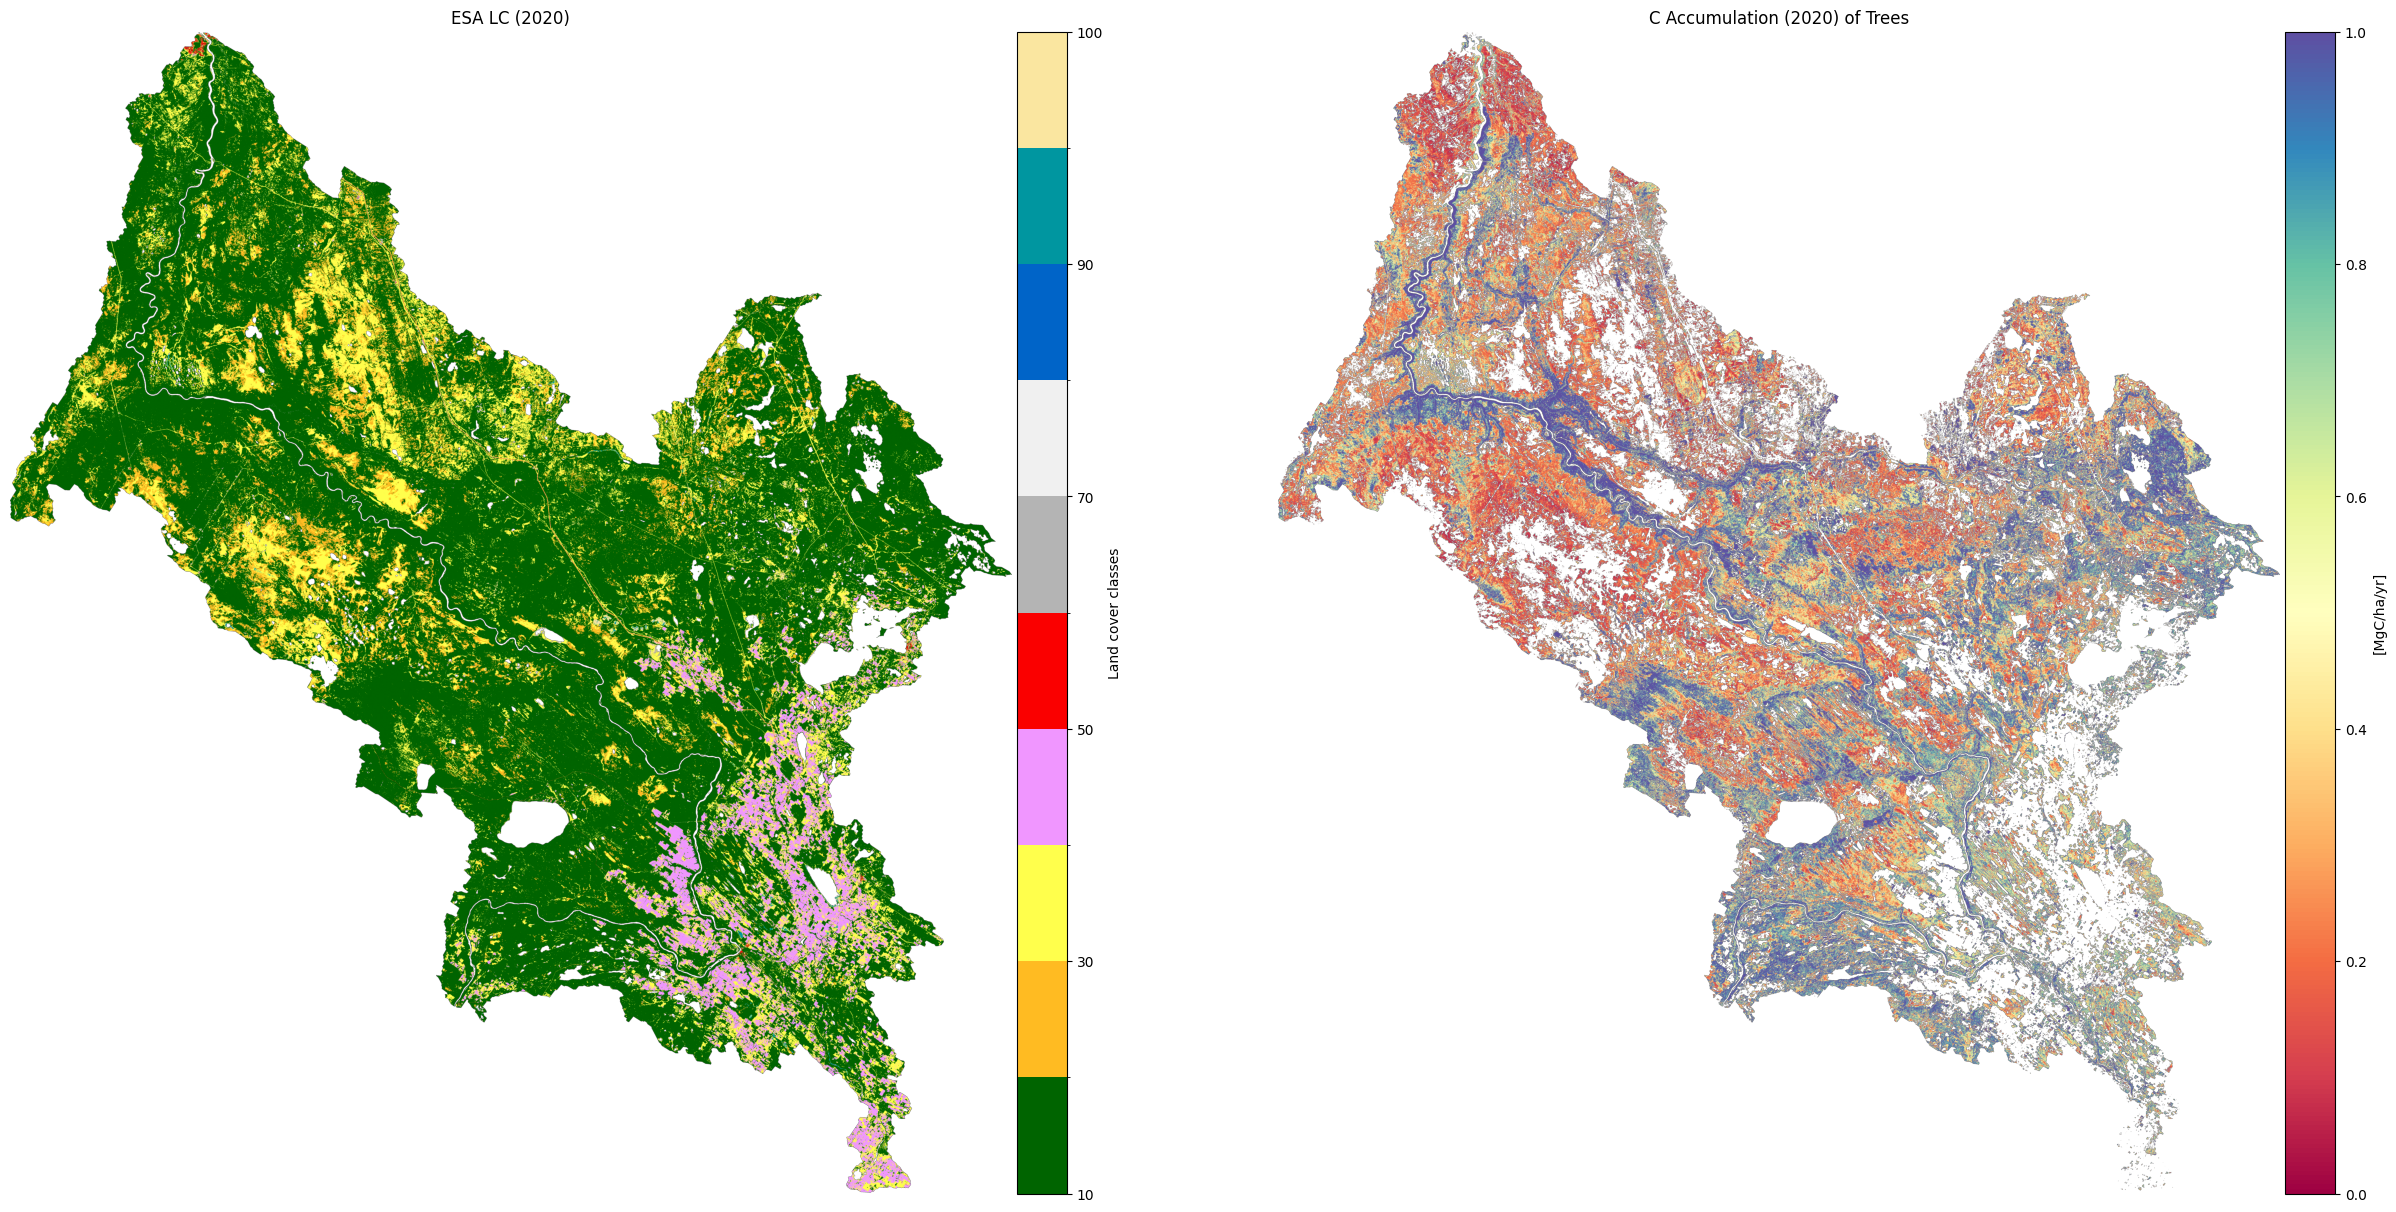

In [345]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(30,30), sharex=True, sharey=True)
# Showing trees instead of all LC classes
m3 = axes[0].imshow(lc_arr_masked, cmap=cmap_worldcover, norm=norm_worldcover)
add_colorbar(m3, 'Land cover classes')
axes[0].set_title('ESA LC (2020)')
axes[0].axis('off')

# Carbon accumulation in trees
m4 = axes[1].imshow(netc_accum_arr_trees, clim=(0,1), cmap='Spectral')
add_colorbar(m4, '[MgC/ha/yr]')
m4 = axes[1].set_title('C Accumulation (2020) of Trees')
axes[1].axis('off')

## Classifiers

#### Stand Age Classes

In [346]:
np.unique(standage_arr_masked).data

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  50, 255],
      dtype=uint8)

In [347]:
standage_classified = np.ma.where(standage_arr_masked == 0, 0, 
                                      np.ma.where( ((standage_arr_masked > 0) & (standage_arr_masked < 36)), 1, 
                                                 np.ma.where(standage_arr_masked >= 36, 2, 3) ))
np.unique(standage_classified).data

array([0, 1, 2, 3])

(-0.5, 8042.5, 9328.5, -0.5)

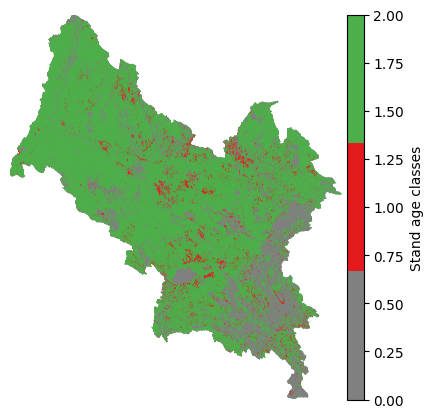

In [348]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5,5), sharex=True, sharey=True)
# Showing trees instead of all LC classes
z = axes.imshow(standage_classified, cmap=cmap_standage)
add_colorbar(z, 'Stand age classes')
axes.axis('off')

In [349]:
def tcctrend_classifier(row):
    if row["TCC_trend"] < -2  :
        return 'decline\n(strong)'
    elif (row["TCC_trend"] >=-2) & (row["TCC_trend"] < -0.5):
        return 'decline\n(weak)'
    elif (row["TCC_trend"] <= 2) & (row["TCC_trend"] > 0.5):
        return 'increase\n(weak)'
    elif row["TCC_trend"] > 2  :
        return 'increase\n(strong)'
    else:
        return "stable"

def tccpval_classifier(row):
    if row["TCC_trend_pval"] >= 0.05 :
        return 'not sig'
    elif row["TCC_trend_pval"] < 0.05:
        return 'sig (p<0.05)'
    elif row["TCC_trend_pval"] < 0.01:
        return 'sig (p<0.01)'
    else:
        return "?"

In [ ]:
arr_list = common_mask([lc_arr_masked, agb_arr_masked, standage_classified, netc_accum_arr, tccslope_arr, tcc2020_arr, tccpvalue_arr], apply=True)

print(arr_list[0].count())

stack = np.stack([arr[(netc_accum_arr>=0) & (tcc2020_arr < 255) & (agb_arr_masked > -9999)].data.flatten() for arr in arr_list],axis=1)
#stack = np.stack([arr.data.flatten() for arr in arr_list], axis=1)
print(stack.shape)

# Common mask
#stack = common_mask(stack, apply=True)

# Build data frame
VARS_LIST = ['LC','Mg_ha', 'Age_class','Mg_C_ha_yr','TCC_trend','TCC_2020', 'TCC_trend_pval']
stack_df = pd.DataFrame(stack, columns = VARS_LIST)

# Clean
stack_df['TCC trend class'] = stack_df.apply(tcctrend_classifier, axis=1)
stack_df['TCC trend class']  = pd.Categorical(stack_df['TCC trend class'] , categories=['decline\n(strong)', 'decline\n(weak)', 'stable', 'increase\n(weak)', 'increase\n(strong)'], ordered=True)
stack_df['TCC_trend_pval_class'] = stack_df.apply(tccpval_classifier, axis=1)
stack_df['TCC_trend_pval_class']  = pd.Categorical(stack_df['TCC_trend_pval_class'] , categories=['not sig', 'sig (p<0.05)', 'sig (p<0.01)'], ordered=True)

remap_dict = dict(zip(values_standage, names_standage))
stack_df['Age_class'] = stack_df['Age_class'].replace(remap_dict)
stack_df['Age_class'] = pd.Categorical(stack_df['Age_class'], categories=names_standage, ordered=True)

remap_dict = dict(zip(values_worldcover, names_worldcover))
stack_df['LC'] = stack_df['LC'].replace(remap_dict)
stack_df['LC'] = pd.Categorical(stack_df['LC'], categories=names_worldcover, ordered=True)

stack_df['Mg'] = stack_df['Mg_ha'] * area_pix_ha
stack_df.head()

24964942
(29806363, 7)


In [ ]:
from plotnine import *

In [ ]:
FILTER_LIST = ['Open water', 'Barren/sparse', 'Built-up']
KEEP_LIST = ['Trees']
(
    ggplot(data=stack_df.dropna()[~stack_df['LC'].isin(FILTER_LIST)], mapping = aes( x='TCC trend class', fill='Age_class') ) 
    + geom_bar(stat='count') # for a regular bar plot - fast
    + scale_fill_manual(values=dict(zip(names_standage, colors_standage)))
    + facet_wrap('~ TCC_trend_pval_class', ncol=4)
    + theme_minimal()
    + theme(figure_size=(10,4))
) 

In [ ]:
FILTER_LIST = ['Open water', 'Barren/sparse', 'Built-up']
KEEP_LIST = ['Trees']
(
    ggplot(data=stack_df.dropna()[~stack_df['LC'].isin(FILTER_LIST)], mapping = aes( x='Age_class', fill='LC') ) 
    + geom_bar(stat='count') # for a regular bar plot - fast
    + scale_fill_manual(values=dict(zip(names_worldcover, cols_worldcover)))
    + theme_minimal()
    + theme(figure_size=(6,4))
) 

### Build summary table

In [ ]:
stack_df_smry = pd.DataFrame(
    stack_df.groupby(["LC","Age_class","TCC trend class","TCC_trend_pval_class"]).agg(
            {
            "Mg": ["sum"], #, "min", "max", "median", "skew", "std", "count"], # np.nansum(netc_accum_arr_trees)/1e9 * area_pix_ha
            "Mg_ha": ["sum"], #, "min", "max", "median", "skew", "std", "count"], # np.nansum(netc_accum_arr_trees)/1e9 * area_pix_ha
            #"Mg_C_ha_yr": ["min", "max", "median", "skew", "std", "count"]#,
            #"Age_yr": ["min", "max", "median", "skew", "std", "count"]
            }
                        )  
)
##stack_df_smry['LC'] = stack_df_smry.index

stack_df_smry.reset_index(drop=False, inplace=True)

stack_df_smry.columns = [' '.join(col).strip() for col in stack_df_smry.columns.values]

# Convert sum to Pg, normalize sum by area of pixel
stack_df_smry['Total AGB [Pg]'] = stack_df_smry['Mg_ha sum']/1e9 * area_pix_ha

### Total Biomass per Stand Age and TCC trend class

In [ ]:
(
    ggplot(data=stack_df_smry.dropna()[~stack_df_smry['LC'].isin(FILTER_LIST)], mapping = aes(y='Total AGB [Pg]', x="TCC trend class", fill='Age_class') ) 
    + geom_bar(stat='identity')
    + scale_fill_manual(values=dict(zip(names_standage, colors_standage)))
    + theme_minimal()
) 

### Total Biomass per land cover class

In [ ]:
(
    ggplot(data=stack_df_smry.dropna()[~stack_df_smry['LC'].isin(FILTER_LIST)], mapping = aes(y='Total AGB [Pg]', x='Age_class', fill='LC') ) 
    + geom_bar(stat='identity')
    + scale_fill_manual(values=dict(zip(names_worldcover, cols_worldcover)))
    + theme_minimal()
) 

In [ ]:
(
    ggplot(data=stack_df_smry.dropna()[~stack_df_smry['LC'].isin(FILTER_LIST)], mapping = aes(y='Total AGB [Pg]', x="Age_class", fill='Age_class') ) 
    + geom_bar(stat='identity')
    + scale_fill_manual(values=dict(zip(names_standage, colors_standage)))
    + theme_minimal()
) 

In [ ]:
(
    ggplot(data=stack_df_smry.dropna()[~stack_df_smry['LC'].isin(FILTER_LIST)], mapping = aes(y="Total AGB [Pg]", x="TCC trend class", fill="Age_class") ) 
    #ggplot(data=stack_df_smry.dropna()[~stack_df_smry['LC'].isin(FILTER_LIST)], mapping = aes(y='Total AGB [Pg]', x='Age_class', fill='Age_class') ) 
    + geom_bar(stat='identity')
    + scale_fill_manual(values=dict(zip(names_standage, colors_standage)))
    + facet_wrap('~ TCC_trend_pval_class', ncol=4)
    + theme_minimal()
    + theme(figure_size=(12,4))
) 

### Stand age, carbon accumulation, and tree cover rate change maps

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(30,30), sharex=True, sharey=True)

# Age
m2 = axes[0].imshow(standage_arr_masked_trees, cmap='nipy_spectral')
add_colorbar(m2, '[yrs]')
axes[0].set_title('Stand Age (2020) of ESA Trees')
axes[0].axis('off')

# Carbon accumulation
m5 = axes[1].imshow(netc_accum_arr_trees, clim=(0,1), cmap='Spectral')
add_colorbar(m5, '[MgC/ha/yr]')
m5 = axes[1].set_title('Net C Accumulation (2020) TerraPulse Forest & ESA Trees')
axes[1].axis('off')

# TCC trend 1984-2020
m6 = axes[2].imshow(tccslope_arr, clim=(-2,2), cmap='BrBG')
add_colorbar(m6, '[%TCC/yr]')
m6 = axes[2].set_title('TCC change rate (%/yr), 1984-2020')
axes[2].axis('off')

### Binned scatterplots

In [ ]:
# Mask TCC trends with 
tccslope_masked = np.ma.masked_where(netc_accum_arr_trees.mask, tccslope_arr)

lims_c_accum = [0,30]
lims_stand_age = [0,50]
lims_tcc_change = [-2, 3]

#Declaring the figure, and hiding the ticks' labels
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24,5))
st = fig.suptitle("Structure and dynamics in Tree land cover", fontsize=20,  horizontalalignment='center')

## Actually Plotting the data
# Binned scatterplots
ax1.hexbin(np.ravel(netc_accum_arr_trees), np.ravel(tccslope_masked), gridsize=100, bins='log', cmap='plasma')
ax2.hexbin(np.ravel(standage_arr_masked_trees), np.ravel(tccslope_masked), gridsize=100, bins='log', cmap='plasma')
ax3.hexbin(np.ravel(standage_arr_masked_trees), np.ravel(agb_arr_masked_trees), gridsize=100, bins='log', cmap='plasma')
hb=ax4.hexbin(np.ravel(standage_arr_masked_trees), np.ravel(netc_accum_arr_trees), gridsize=100, bins='log', cmap='plasma')


# Scatterplots
#ax1.scatter(np.ravel(netc_accum_arr_trees), np.ravel(tccslope_masked),  s=0.1, c='black', alpha=0.01)
#ax2.scatter(np.ravel(standage_arr_masked_trees), np.ravel(tccslope_masked),  s=0.1, c='black', alpha=0.01)
#ax3.scatter(np.ravel(standage_arr_masked_trees), np.ravel(netc_accum_arr_trees),  s=0.1, c='black', alpha=0.01)

#Making the graph pretty and informative!
ax1.set_title("tree cover rate of change 1984-2020", fontsize=16)
ax1.set_ylabel("Rate of change [%]", fontsize=16)
ax1.set_xlabel("[MgC/Ha/yr]", fontsize=16)
ax1.set_ylim(lims_tcc_change)

ax2.set_title("tree cover rate of change 1984-2020", fontsize=16)
ax2.set_xlabel("[Stand age]", fontsize=16)
ax2.set_ylim(lims_tcc_change)

ax3.set_title("AGB density in trees", fontsize=16)
ax3.set_ylabel("[Mg/Ha]", fontsize=16)
ax3.set_ylim((0,150))
ax3.set_xlabel("[Stand age]", fontsize=16)

ax4.set_title("Net C accumulation in trees", fontsize=16)
ax4.set_ylabel("[MgC/Ha/yr]", fontsize=16)
ax4.set_ylim(lims_c_accum)
ax4.set_xlabel("[Stand age]", fontsize=16)
ax4.text(0.80,
         1.0, 
         f"extent = {extent_id}",
         transform=plt.gca().transAxes,
         color = "black",
         fontsize=8
        )
cb = fig.colorbar(hb, ax=ax4)
cb.set_label('log10(N)')

# shift subplots down:
st.set_y(0.95)
fig.subplots_adjust(top=0.65)

ax1.set_xlim(lims_c_accum)
#ax1.set_xscale('log')
ax2.set_xlim(lims_stand_age)
ax3.set_xlim(lims_stand_age)
ax4.set_xlim(lims_stand_age)
plt.show()

# Try this next but need to remove nans from each array: https://stackoverflow.com/questions/20105364/how-can-i-make-a-scatter-plot-colored-by-density-in-matplotlib

## Questions to answer
For trees in stands =< 36 yrs, 
1. what is the total AGB (Pg) and what is C?  
2. what is the percentage of overall C?

## Write a new stack
Band 1: ESA WorldCover  
Band 2: ABoVE AGB for ESA veg mask  
Band 3: ABoVE AGB for ESA tree mask  
Band 4: ABoVE Net C accumulation in trees with stand age (TP forest stand age x ESA tree mask ) 
 - not doing this stack correctly - fill value and nodata need to be looked at


In [ ]:
out_stack_fn = os.path.join(os.path.dirname(BASIN_COG_DICT['biomass_cog_fn']) , f"boreal_dynamics_trees_{ID}.tif").replace('s3://maap-ops-workspace/shared/montesano','/projects/my-public-bucket/')
out_stack_fn

In [ ]:
# Stack
# move axis of the stack so bands is first
# LC array (int) mask filled with 0 .... AGB arrays (floats) filled with nan
#analysis_stack = np.stack([lc_arr.filled(0) , agb_arr_masked.filled(-9999) , agb_arr_masked_trees.filled(-9999) ])
analysis_stack = np.stack([lc_arr, agb_arr_masked , agb_arr_masked_trees,  standage_arr_masked_trees, tccslope_masked])
analysis_stack_names = ["lc", "agb_veg", "agb_tree", "stand_age", "tcc_trend"]

# Copy input agb metadata
out_meta = dataset_agb.profile
out_meta

# write COG to disk
write_cog(
            analysis_stack, 
            out_stack_fn, 
            out_meta['crs'], 
            out_meta['transform'], 
            analysis_stack_names, 
            out_crs=out_meta['crs'],
    input_nodata_value= -9999
             )

# Stack the masked data and build a dataframe
https://stackoverflow.com/questions/10373660/converting-a-pandas-groupby-output-from-series-to-dataframe

In [124]:
#Return a common mask for a set of input ma
def common_mask(ma_list, apply=False):
    if type(ma_list) is not list:
        print("Input must be list of masked arrays")
        return None
    #Note: a.mask will return single False if all elements are False
    #np.ma.getmaskarray(a) will return full array of False
    #ma_list = [np.ma.array(a, mask=np.ma.getmaskarray(a), shrink=False) for a in ma_list]
    a = np.ma.array(ma_list, shrink=False)
    #Check array dimensions
    #Check dtype = bool
    #Masked values are listed as true, so want to return any()
    #a+b+c - OR (any)
    mask = np.ma.getmaskarray(a).any(axis=0)
    #a*b*c - AND (all)
    #return a.all(axis=0)
    if apply:
        return [np.ma.array(b, mask=mask) for b in ma_list] 
    else:
        return mask

In [68]:
%matplotlib inline



#
# --UPDATE TO A COMMON MASK for the stack
#
arr_list = common_mask([lc_arr_masked, agb_arr_masked, standage_arr_masked, netc_accum_arr, tccslope_arr, tcc2020_arr], apply=True)
#arr_list = [lc_arr_masked, agb_arr_masked, standage_arr_masked, netc_accum_arr, tccslope_arr, tcc2020_arr]

print(arr_list[0].count())
stack = np.stack([arr[(netc_accum_arr>=0) & (tcc2020_arr < 255)].data.flatten() for arr in arr_list],axis=1)

# Common mask
#stack = common_mask(stack, apply=True)

# Build data frame
VARS_LIST = ['LC','Mg_ha', 'Age_yr','Mg_C_ha_yr','TCC_slope','TCC_2020']
stack_df = pd.DataFrame(stack, columns = VARS_LIST)

# Clean
stack_df['Age_yr'] = stack_df['Age_yr'].apply(int)
remap_dict = dict(zip(values_worldcover, names_worldcover))
stack_df['LC'] = stack_df['LC'].replace(remap_dict)
stack_df['LC'] = pd.Categorical(stack_df['LC'], categories=names_worldcover, ordered=True)
stack_df.info()

333604
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348000 entries, 0 to 347999
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   LC          348000 non-null  category
 1   Mg_ha       348000 non-null  float64 
 2   Age_yr      348000 non-null  int64   
 3   Mg_C_ha_yr  348000 non-null  float64 
 4   TCC_slope   348000 non-null  float64 
 5   TCC_2020    348000 non-null  float64 
dtypes: category(1), float64(4), int64(1)
memory usage: 13.6 MB


### Histogram of TCC rate of change, 1984-2020

In [69]:
stack_df.head()
# -- get a summary here to check that invalid values are removed

,LC,Mg_ha,Age_yr,Mg_C_ha_yr,TCC_slope,TCC_2020
0,Trees,66.979851,50,0.669799,0.000000,83.0
1,Open water,39.712601,0,39.712601,0.613729,81.0
2,Trees,63.197826,50,0.631978,0.000000,84.0
3,Trees,41.164677,50,0.411647,0.039829,73.0
4,Trees,33.391151,50,0.333912,0.348269,69.0
